<a href="https://colab.research.google.com/github/junhaePark/machineLearning/blob/main/IWannaGoHome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. 데이터 파일 로드
colab_path = "/content/gdrive/MyDrive/Kisia/Data/"
df = pd.read_csv(colab_path + "7_seoul_2025_transaction.csv")

In [90]:
df.isnull()

,aptDong,aptNm,buildYear,buyerGbn,cdealDay,cdealType,dealAmount,dealDay,dealMonth,dealYear,...,excluUseAr,floor,jibun,landLeaseholdGbn,rgstDate,sggCd,slerGbn,umdNm,yyyymm,lawd_cd
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77732,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
77733,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
77734,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
77735,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [91]:
# 2. 한글 폰트 설정 (Colab용, 그래프에서 한글 깨짐 방지)
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fontpath = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

In [92]:
# 3. 거래금액 전처리 (콤마 제거 후 숫자로 변환, 만원 단위)
df['dealAmount'] = df['dealAmount'].str.replace(',', '').astype(int)

In [86]:
# 주요 feature 결측치 제거
key_cols = ['dealAmount', 'excluUseAr', 'floor', 'buildYear', 'sggCd']
df = df.dropna(subset=key_cols)
df = df[(df['dealAmount'] > 0) & (df['excluUseAr'] > 0)]  # 이상값 방지
df = df[df['cdealType'] != 'O']  # 해제된 계약 제거
df = df[df['dealingGbn'] == '중개거래']  # 직거래 제외하고 순수 시세만 분석

df['건축연차'] = 2025 - df['buildYear']
df['평당가'] = df['dealAmount'] / (df['excluUseAr'] / 3.3058)

gu_map = {
    11110: '종로구', 11140: '중구', 11170: '용산구', 11200: '성동구',
    11215: '광진구', 11230: '동대문구', 11260: '중랑구', 11290: '성북구',
    11305: '강북구', 11320: '도봉구', 11380: '은평구', 11410: '서대문구',
    11440: '마포구', 11470: '양천구', 11500: '강서구', 11530: '구로구',
    11545: '금천구', 11560: '영등포구', 11590: '동작구', 11620: '관악구',
    11650: '서초구', 11680: '강남구', 11710: '송파구', 11740: '강동구'
}
df['구'] = df['sggCd'].map(gu_map)

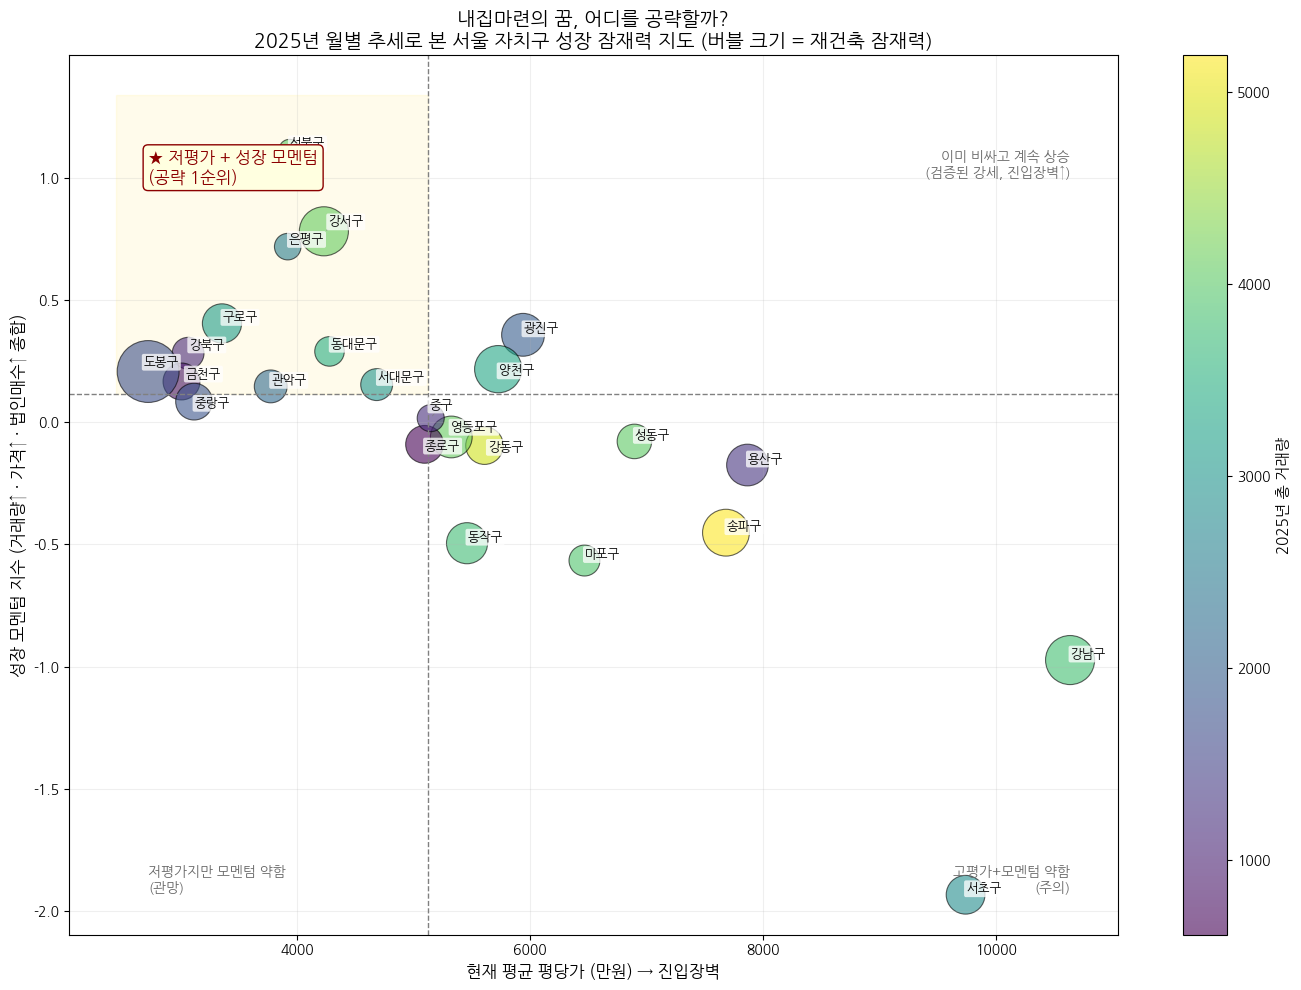

=== 저평가 + 성장 모멘텀 상위 지역 ===
       구        현재평당가   성장모멘텀지수      노후비중  총거래량
15   성북구  3932.691840  1.113287  0.025514  4037
3    강서구  4228.535438  0.779986  0.366464  4115
20   은평구  3917.809039  0.717207  0.071795  2535
6    구로구  3353.162050  0.403214  0.215636  3121
9   동대문구  4276.876592  0.288736  0.101124  3471
2    강북구  3062.183075  0.281176  0.124668  1131
8    도봉구  2718.684930  0.206500  0.611923  1711
7    금천구  3005.356302  0.165733  0.185629   835
12  서대문구  4681.911521  0.152960  0.125799  2973
4    관악구  3771.860998  0.145653  0.136635  2181


In [87]:
# ===== 3. 구별 월간 지표 집계 =====
monthly = df.groupby(['구', 'dealMonth']).agg(
    거래량=('dealAmount', 'count'),
    평균평당가=('평당가', 'mean')
).reset_index()

# ===== 4. sklearn 회귀로 "월별 추세 기울기" 계산 (모멘텀) =====
def get_slope(sub, ycol):
    X = sub[['dealMonth']].values
    y = sub[ycol].values
    model = LinearRegression().fit(X, y)
    return model.coef_[0]

momentum_records = []
for gu, sub in monthly.groupby('구'):
    sub = sub.sort_values('dealMonth')
    vol_slope = get_slope(sub, '거래량')          # 월별 거래량 증가 기울기
    price_slope = get_slope(sub, '평균평당가')     # 월별 평당가 증가 기울기
    momentum_records.append({'구': gu, '거래량모멘텀': vol_slope, '가격모멘텀': price_slope})

momentum_df = pd.DataFrame(momentum_records)

# ===== 5. 구별 종합 지표 (기존 코드에 매도자 정보 추가) =====
gu_summary = df.groupby('구').agg(
    현재평당가=('평당가', 'mean'),
    평균건축연차=('건축연차', 'mean'),
    노후비중=('건축연차', lambda x: (x >= 30).mean()),
    총거래량=('dealAmount', 'count'),
    법인매수비중=('buyerGbn', lambda x: (x == '법인').mean()),
    법인매도비중=('slerGbn', lambda x: (x == '법인').mean()),        # 추가
    공공매도비중=('slerGbn', lambda x: (x == '공공기관').mean())      # 추가
).reset_index()

gu_summary = gu_summary.merge(momentum_df, on='구')

# ===== 6. 표준화 후 "성장 모멘텀 지수" 합성 (매도자 신호 추가) =====
scaler = StandardScaler()
z = scaler.fit_transform(
    gu_summary[['거래량모멘텀', '가격모멘텀', '법인매수비중', '공공매도비중']]
)
gu_summary['성장모멘텀지수'] = (
    z[:, 0] * 0.35        # 거래량모멘텀
    + z[:, 1] * 0.35      # 가격모멘텀
    + z[:, 2] * 0.15      # 법인매수비중 (수요 신호)
    + z[:, 3] * 0.15      # 공공매도비중 (공급/분양 신호)
)

# ===== 7. 시각화: 사분면 차트 =====
fig, ax = plt.subplots(figsize=(14, 10))

x_med = gu_summary['현재평당가'].median()
y_med = gu_summary['성장모멘텀지수'].median()

# 사분면 배경 색칠
from matplotlib.patches import Rectangle
ax.add_patch(Rectangle(
    (gu_summary['현재평당가'].min()*0.9, y_med),
    x_med - gu_summary['현재평당가'].min()*0.9,
    gu_summary['성장모멘텀지수'].max()*1.2 - y_med,
    color='gold', alpha=0.08, zorder=0
))

sizes = gu_summary['노후비중'] * 3000 + 150   # 노후비중 클수록 = 재건축 잠재력 클수록 버블 큼

scatter = ax.scatter(
    gu_summary['현재평당가'], gu_summary['성장모멘텀지수'],
    s=sizes, c=gu_summary['총거래량'], cmap='viridis',
    alpha=0.6, edgecolors='black', linewidth=0.8
)

!pip install adjustText -q
from adjustText import adjust_text

texts = []
for _, row in gu_summary.iterrows():
    t = ax.annotate(
        row['구'], (row['현재평당가'], row['성장모멘텀지수']),
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75)
    )
    texts.append(t)

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.axvline(x_med, color='gray', linestyle='--', linewidth=1)
ax.axhline(y_med, color='gray', linestyle='--', linewidth=1)

# 사분면 라벨
ax.text(gu_summary['현재평당가'].min(), gu_summary['성장모멘텀지수'].max(),
        '★ 저평가 + 성장 모멘텀\n(공략 1순위)', fontsize=12, fontweight='bold',
        color='darkred', va='top', ha='left',
        bbox=dict(boxstyle='round', fc='lightyellow', ec='darkred'))

ax.text(gu_summary['현재평당가'].max(), gu_summary['성장모멘텀지수'].max(),
        '이미 비싸고 계속 상승\n(검증된 강세, 진입장벽↑)', fontsize=10,
        va='top', ha='right', color='dimgray')

ax.text(gu_summary['현재평당가'].min(), gu_summary['성장모멘텀지수'].min(),
        '저평가지만 모멘텀 약함\n(관망)', fontsize=10, va='bottom', ha='left', color='dimgray')

ax.text(gu_summary['현재평당가'].max(), gu_summary['성장모멘텀지수'].min(),
        '고평가+모멘텀 약함\n(주의)', fontsize=10, va='bottom', ha='right', color='dimgray')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('2025년 총 거래량', fontsize=11)

ax.set_xlabel('현재 평균 평당가 (만원) → 진입장벽', fontsize=12)
ax.set_ylabel('성장 모멘텀 지수 (거래량↑ · 가격↑ · 법인매수↑ 종합)', fontsize=12)
ax.set_title(
    '내집마련의 꿈, 어디를 공략할까?\n'
    '2025년 월별 추세로 본 서울 자치구 성장 잠재력 지도 (버블 크기 = 재건축 잠재력)',
    fontsize=14, fontweight='bold'
)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('seoul_apt_opportunity_map.jpg', dpi=200)
plt.show()

# ===== 8. 공략 1순위 지역 텍스트 출력 =====
target = gu_summary[
    (gu_summary['현재평당가'] < x_med) & (gu_summary['성장모멘텀지수'] > y_med)
].sort_values('성장모멘텀지수', ascending=False)
print("=== 저평가 + 성장 모멘텀 상위 지역 ===")
print(target[['구', '현재평당가', '성장모멘텀지수', '노후비중', '총거래량']])